In [ ]:
"""This project explores a dataset named coffee_shop_revenue.csv to:

Understand how different features affect daily revenue.

Use Simple Linear Regression (one feature) and Multiple Linear Regression (multiple features) to predict revenue.

Evaluate which model is more accurate.

Visualize the relationships and predictions using charts.

"""


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('coffee_shop_revenue.csv')

In [3]:
df.head()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42


In [4]:
print("Predictor Variables:")
print(list(df.columns[:-1]))
print("\nDependent Variable:")
print(df.columns[-1])

Predictor Variables:
['Number_of_Customers_Per_Day', 'Average_Order_Value', 'Operating_Hours_Per_Day', 'Number_of_Employees', 'Marketing_Spend_Per_Day', 'Location_Foot_Traffic']

Dependent Variable:
Daily_Revenue


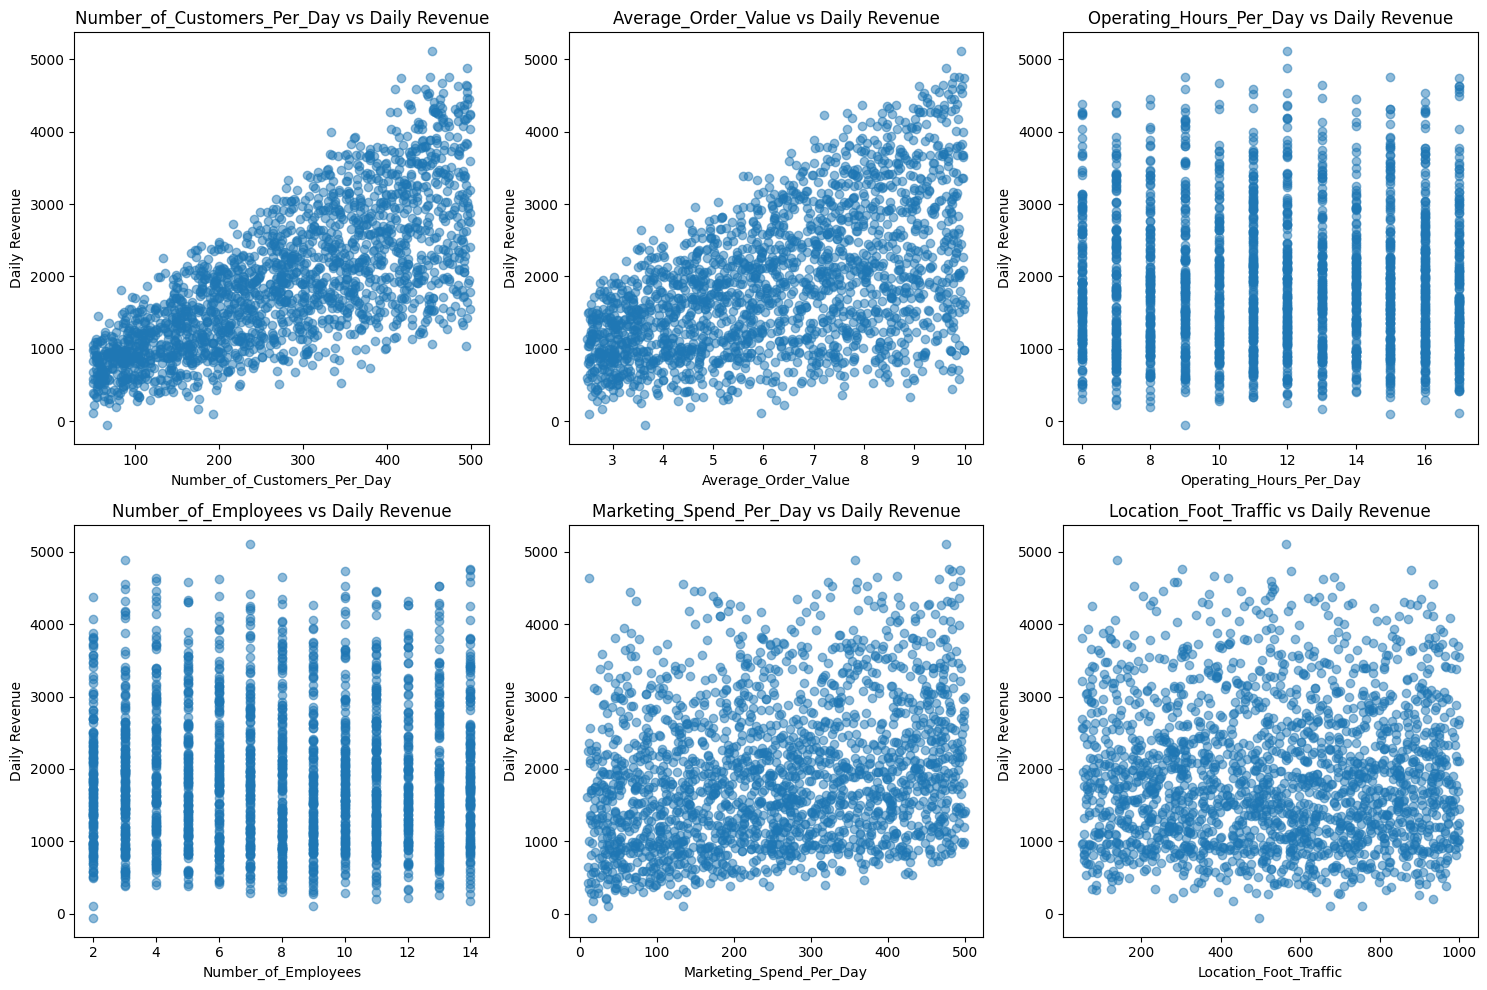

In [9]:
predictors = df.columns[:-1]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, predictor in enumerate(predictors):
    axes[idx].scatter(df[predictor], df['Daily_Revenue'], alpha=0.5)
    axes[idx].set_xlabel(predictor)
    axes[idx].set_ylabel('Daily Revenue')
    axes[idx].set_title(f'{predictor} vs Daily Revenue')

plt.tight_layout()

In [10]:
X = df[['Number_of_Customers_Per_Day']]
y = df['Daily_Revenue']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
simple_lr = LinearRegression()
simple_lr.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred_simple = simple_lr.predict(X_test)

In [14]:
simple_mse = mean_squared_error(y_test, y_pred_simple)
simple_r2 = r2_score(y_test, y_pred_simple)
print("\nSimple Linear Regression Results:")
print(f"Mean Squared Error: {simple_mse:.2f}")
print(f"R-squared Score: {simple_r2:.2f}")


Simple Linear Regression Results:
Mean Squared Error: 401391.88
R-squared Score: 0.57


Text(0.5, 1.0, 'Simple Linear Regression: Actual vs Predicted')

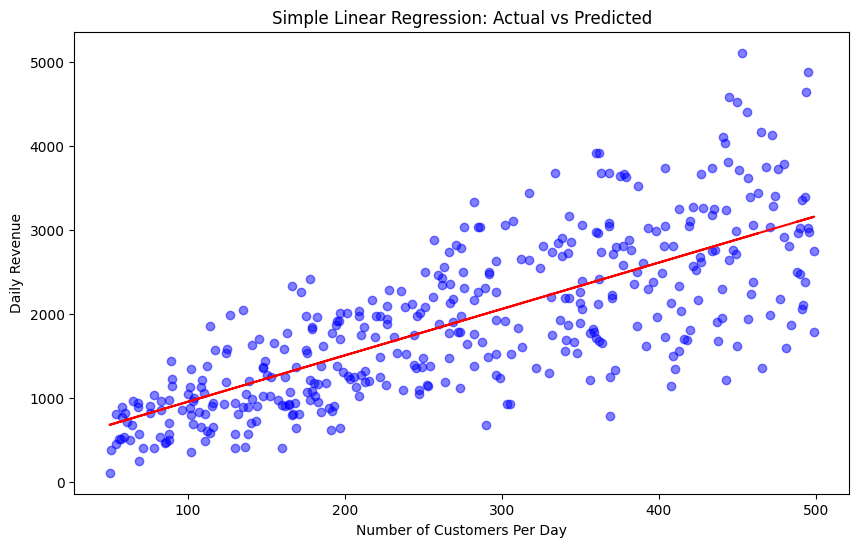

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual')
plt.plot(X_test, y_pred_simple, color='red', label='Predicted')
plt.xlabel('Number of Customers Per Day')
plt.ylabel('Daily Revenue')
plt.title('Simple Linear Regression: Actual vs Predicted')

In [15]:
X_multi = df.drop('Daily_Revenue', axis=1)
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y, test_size=0.2, random_state=42)

In [16]:
# Build and train model
multi_lr = LinearRegression()
multi_lr.fit(X_train_multi, y_train_multi)

LinearRegression()

In [17]:
y_pred_multi = multi_lr.predict(X_test_multi)

In [18]:
multi_mse = mean_squared_error(y_test_multi, y_pred_multi)
multi_r2 = r2_score(y_test_multi, y_pred_multi)


In [19]:
print("\nMultiple Linear Regression Results:")
print(f"Mean Squared Error: {multi_mse:.2f}")
print(f"R-squared Score: {multi_r2:.2f}")


Multiple Linear Regression Results:
Mean Squared Error: 97569.72
R-squared Score: 0.90


Text(0.5, 1.0, 'Multiple Linear Regression: Actual vs Predicted')

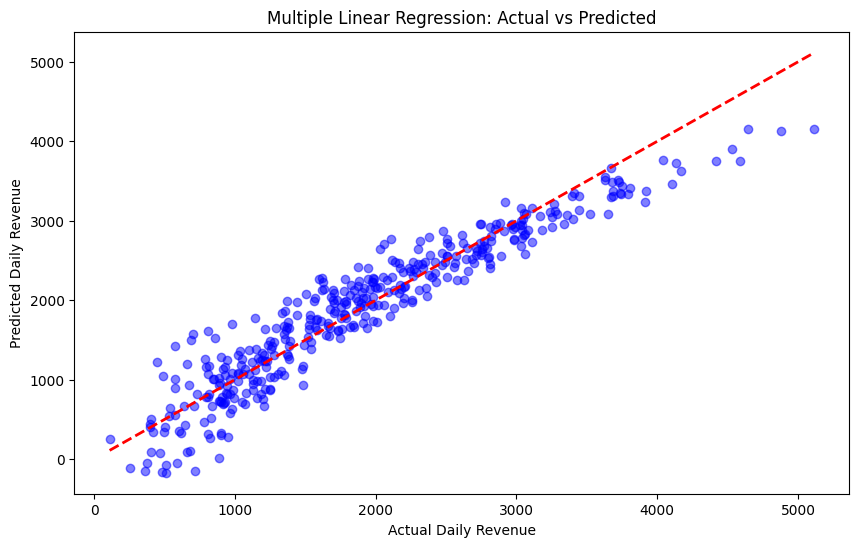

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_multi, y_pred_multi, color='blue', alpha=0.5)
plt.plot([y_test_multi.min(), y_test_multi.max()], [y_test_multi.min(), y_test_multi.max()], 'r--', lw=2)
plt.xlabel('Actual Daily Revenue')
plt.ylabel('Predicted Daily Revenue')
plt.title('Multiple Linear Regression: Actual vs Predicted')

In [20]:
print("\nMSE Comparison:")
print(f"Simple Linear Regression MSE: {simple_mse:.2f}")
print(f"Multiple Linear Regression MSE: {multi_mse:.2f}")
print(f"Difference (Simple - Multiple): {(simple_mse - multi_mse):.2f}")


MSE Comparison:
Simple Linear Regression MSE: 401391.88
Multiple Linear Regression MSE: 97569.72
Difference (Simple - Multiple): 303822.16


In [ ]:
"""1. Importing Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
📌 Explanation:
pandas: for loading and manipulating data.

numpy: for numerical operations (though not used directly here).

matplotlib.pyplot & seaborn: for data visualization (scatter plots, line plots, etc.).

train_test_split: for splitting data into training and testing sets.

LinearRegression: the model used for prediction.

mean_squared_error, r2_score: evaluation metrics.

📥 2. Load and View the Dataset

df = pd.read_csv('coffee_shop_revenue.csv')
df.head()
📌 Explanation:
Loads a CSV file containing coffee shop data (each row = one record, each column = one feature).

.head() shows the first 5 records to help you understand the structure.

📋 3. Identify Predictor and Target Variables

print("Predictor Variables:")
print(list(df.columns[:-1]))
print("\nDependent Variable:")
print(df.columns[-1])
📌 Explanation:
Predictors: Features used to predict revenue (e.g., number of customers, advertisements).

Dependent variable: Daily_Revenue – this is what we want to predict.

This code assumes the last column in the CSV is the revenue.

📊 4. Visualize Relationships (Exploratory Data Analysis)

predictors = df.columns[:-1]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, predictor in enumerate(predictors):
    axes[idx].scatter(df[predictor], df['Daily_Revenue'], alpha=0.5)
    axes[idx].set_xlabel(predictor)
    axes[idx].set_ylabel('Daily Revenue')
    axes[idx].set_title(f'{predictor} vs Daily Revenue')

plt.tight_layout()
📌 Explanation:
Draws scatter plots of each feature against Daily_Revenue.

Helps identify which variables have a linear trend with revenue (important for regression).

alpha=0.5: makes overlapping dots semi-transparent for better visibility.

📈 5. Simple Linear Regression (1 Feature)

X = df[['Number_of_Customers_Per_Day']]
y = df['Daily_Revenue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
📌 Explanation:
Chooses only one predictor: Number_of_Customers_Per_Day.

X_train, X_test: features for training and testing.

y_train, y_test: target values (daily revenue) for training and testing.

test_size=0.2: 20% of data is kept for testing.

random_state=42: ensures results are reproducible.


simple_lr = LinearRegression()
simple_lr.fit(X_train, y_train)
y_pred_simple = simple_lr.predict(X_test)
📌 Explanation:
Trains a Simple Linear Regression model on the training data.

Predicts revenue on test data.


simple_mse = mean_squared_error(y_test, y_pred_simple)
simple_r2 = r2_score(y_test, y_pred_simple)
📌 Explanation:
MSE: Measures average squared difference between actual and predicted values (lower is better).

R-squared: Explains how well the model captures the variance in revenue (closer to 1 is better).

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual')
plt.plot(X_test, y_pred_simple, color='red', label='Predicted')
plt.xlabel('Number of Customers Per Day')
plt.ylabel('Daily Revenue')
plt.title('Simple Linear Regression: Actual vs Predicted')
📌 Explanation:
Plots the actual revenue values (scatter plot) and predicted revenue (red line).

Shows how close predictions are to actual values.

📊 6. Multiple Linear Regression (All Features)

X_multi = df.drop('Daily_Revenue', axis=1)
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y, test_size=0.2, random_state=42)
📌 Explanation:
Uses all features except Daily_Revenue as predictors.


multi_lr = LinearRegression()
multi_lr.fit(X_train_multi, y_train_multi)
y_pred_multi = multi_lr.predict(X_test_multi)
📌 Explanation:
Trains and tests a multiple linear regression model.


multi_mse = mean_squared_error(y_test_multi, y_pred_multi)
multi_r2 = r2_score(y_test_multi, y_pred_multi)
📌 Explanation:
Evaluates the multiple regression model using the same metrics.


plt.figure(figsize=(10, 6))
plt.scatter(y_test_multi, y_pred_multi, color='blue', alpha=0.5)
plt.plot([y_test_multi.min(), y_test_multi.max()], [y_test_multi.min(), y_test_multi.max()], 'r--', lw=2)
plt.xlabel('Actual Daily Revenue')
plt.ylabel('Predicted Daily Revenue')
plt.title('Multiple Linear Regression: Actual vs Predicted')
📌 Explanation:
Plots actual vs predicted revenue.

Red dashed line shows perfect prediction line (ideal scenario).

More scattered points = worse predictions.

📊 7. Compare Simple vs Multiple Linear Regression

print("\nMSE Comparison:")
print(f"Simple Linear Regression MSE: {simple_mse:.2f}")
print(f"Multiple Linear Regression MSE: {multi_mse:.2f}")
print(f"Difference (Simple - Multiple): {(simple_mse - multi_mse):.2f}")
📌 Explanation:
Prints and compares error from both models.

If multiple regression has lower MSE, it means using more features helped improve predictions."""